# Transfer Learning Clustering — Museum Collection Images
## EfficientNetB0 (ImageNet) → UMAP → K-Means / GMM / HDBSCAN
---
**Strategi**: Alih-alih melatih autoencoder dari nol (yang gagal pada dataset kecil),
notebook ini menggunakan **EfficientNetB0 pretrained ImageNet** sebagai feature extractor.
Model ini sudah dilatih pada 1.2 juta gambar sehingga fiturnya jauh lebih kaya dan diskriminatif.

| Tahap | Metode | Tujuan |
|---|---|---|
| 1 | EfficientNetB0 (frozen) | Ekstraksi fitur 1280-dim per gambar |
| 2 | L2 Normalize + PCA/UMAP | Reduksi dimensi + normalisasi |
| 3 | Silhouette + Elbow | Cari K optimal |
| 4 | K-Means / GMM / HDBSCAN | 3 metode clustering berbeda |
| 5 | Hungarian Algorithm | Validasi vs ground truth folder |

> **Dataset**: 593 file `.heic` dari 10 kategori koleksi museum  
> **Environment**: Lokal Mac, `cv_daun` conda env


## Cell 1 — Install & Import Library

In [1]:
# ============================================================
# CELL 1: INSTALL & IMPORT
# Jalankan sekali jika ada yang belum terinstall:
# !pip install umap-learn hdbscan pillow-heif
# ============================================================

# ── NUMPY COMPATIBILITY PATCH (wajib sebelum import TF) ─────
import numpy as np
_np_compat = {
    'complex_': np.complex128, 'bool': np.bool_,
    'int': np.int_,  'float': np.float64,
    'object': np.object_, 'str': np.str_,
}
for _a, _v in _np_compat.items():
    if not hasattr(np, _a): setattr(np, _a, _v)
del _np_compat, _a, _v
print('[OK] numpy patch applied')

# ── STANDARD LIBS ───────────────────────────────────────────
import os, json, time, shutil, warnings, csv
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from collections import Counter
from scipy.optimize import linear_sum_assignment

# ── SKLEARN ─────────────────────────────────────────────────
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    davies_bouldin_score, calinski_harabasz_score,
    confusion_matrix
)
from sklearn.preprocessing import LabelEncoder

# ── TENSORFLOW / KERAS ──────────────────────────────────────
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras import Model

# ── UMAP (opsional, fallback ke PCA jika tidak ada) ─────────
try:
    import umap
    UMAP_AVAILABLE = True
    print('[OK] UMAP tersedia')
except ImportError:
    UMAP_AVAILABLE = False
    print('[WARN] UMAP tidak ada. Install: pip install umap-learn')
    print('       Akan menggunakan PCA sebagai fallback.')

# ── HDBSCAN (opsional) ───────────────────────────────────────
try:
    import hdbscan
    HDBSCAN_AVAILABLE = True
    print('[OK] HDBSCAN tersedia')
except ImportError:
    HDBSCAN_AVAILABLE = False
    print('[WARN] HDBSCAN tidak ada. Install: pip install hdbscan')

# ── PILLOW-HEIF ─────────────────────────────────────────────
try:
    import pillow_heif
    pillow_heif.register_heif_opener()
    HEIF_SUPPORT = True
    print('[OK] pillow-heif HEIC support aktif')
except ImportError:
    HEIF_SUPPORT = False
    print('[ERROR] pillow-heif tidak ada! pip install pillow-heif')

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'\nTensorFlow : {tf.__version__}')
print(f'GPU/Metal  : {tf.config.list_physical_devices("GPU")}')
print(f'numpy      : {np.__version__}')


/var/folders/mf/x_0m7kcs6znc5rzgbv845mb00000gn/T/ipykernel_35521/769198583.py:15: FutureWarning: In the future `np.bool` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, _a): setattr(np, _a, _v)
/var/folders/mf/x_0m7kcs6znc5rzgbv845mb00000gn/T/ipykernel_35521/769198583.py:15: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, _a): setattr(np, _a, _v)
/var/folders/mf/x_0m7kcs6znc5rzgbv845mb00000gn/T/ipykernel_35521/769198583.py:15: FutureWarning: In the future `np.str` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, _a): setattr(np, _a, _v)


[OK] numpy patch applied


/opt/homebrew/Caskroom/miniforge/base/envs/cv_daun/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[OK] UMAP tersedia
[OK] HDBSCAN tersedia
[OK] pillow-heif HEIC support aktif

TensorFlow : 2.16.2
GPU/Metal  : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
numpy      : 1.26.4


## Cell 2 — Konfigurasi Global

In [2]:
# ============================================================
# CELL 2: KONFIGURASI
# ============================================================

CONFIG = {
    # ── PATH ─────────────────────────────────────────────────
    'dataset_path'   : '/Users/mdaffaatstsaqif/Downloads/klaster asli',
    'output_root'    : '/Users/mdaffaatstsaqif/Downloads/klaster asli/hasil_transfer',
    'valid_ext'      : ('.jpg', '.jpeg', '.png', '.bmp', '.heic'),

    # ── PREPROCESSING ────────────────────────────────────────
    'img_size'       : 224,    # EfficientNet default input size
    'batch_size'     : 16,     # batch saat ekstraksi fitur

    # ── FEATURE EXTRACTOR ────────────────────────────────────
    'backbone'       : 'EfficientNetB0',  # pretrained model
    'pooling'        : 'avg',             # global average pooling

    # ── DIMENSIONALITY REDUCTION ─────────────────────────────
    'pca_dim'        : 128,   # PCA sebelum clustering / UMAP
    'umap_dim'       : 50,    # UMAP target dimension
    'umap_n_neighbors': 15,
    'umap_min_dist'  : 0.1,

    # ── K SEARCH ─────────────────────────────────────────────
    'k_range'        : list(range(2, 16)),
    'k_fixed'        : 10,    # sesuai jumlah folder museum

    # ── CLUSTERING ───────────────────────────────────────────
    'kmeans_n_init'  : 50,
    'gmm_n_init'     : 5,
    'hdbscan_min_cluster_size': 8,

    # ── VISUALISASI ──────────────────────────────────────────
    'n_sample_vis'   : 6,
    'tsne_perplexity': 30,
}

for subdir in ['grafik', 'cluster_kmeans', 'cluster_gmm', 'cluster_hdbscan']:
    os.makedirs(os.path.join(CONFIG['output_root'], subdir), exist_ok=True)

print('Config OK. Output dir:', CONFIG['output_root'])


Config OK. Output dir: /Users/mdaffaatstsaqif/Downloads/klaster asli/hasil_transfer


## Cell 3 — Load Dataset + Ground Truth Labels

Total file   : 593
Kategori     : 10
  [00] koleksi arkeologi                 81 gambar
  [01] koleksi biologi                   48 gambar
  [02] koleksi etnografi                124 gambar
  [03] koleksi geologi                   21 gambar
  [04] koleksi keramik                  112 gambar
  [05] koleksi kesenian                  38 gambar
  [06] koleksi naskah kuno               47 gambar
  [07] koleksi numismatik                50 gambar
  [08] koleksi senjata                   12 gambar
  [09] koleksi teknologika               60 gambar


Loading: 100%|██████████| 593/593 [01:58<00:00,  5.02it/s]



Berhasil dimuat : 593 gambar
Shape           : (593, 224, 224, 3)


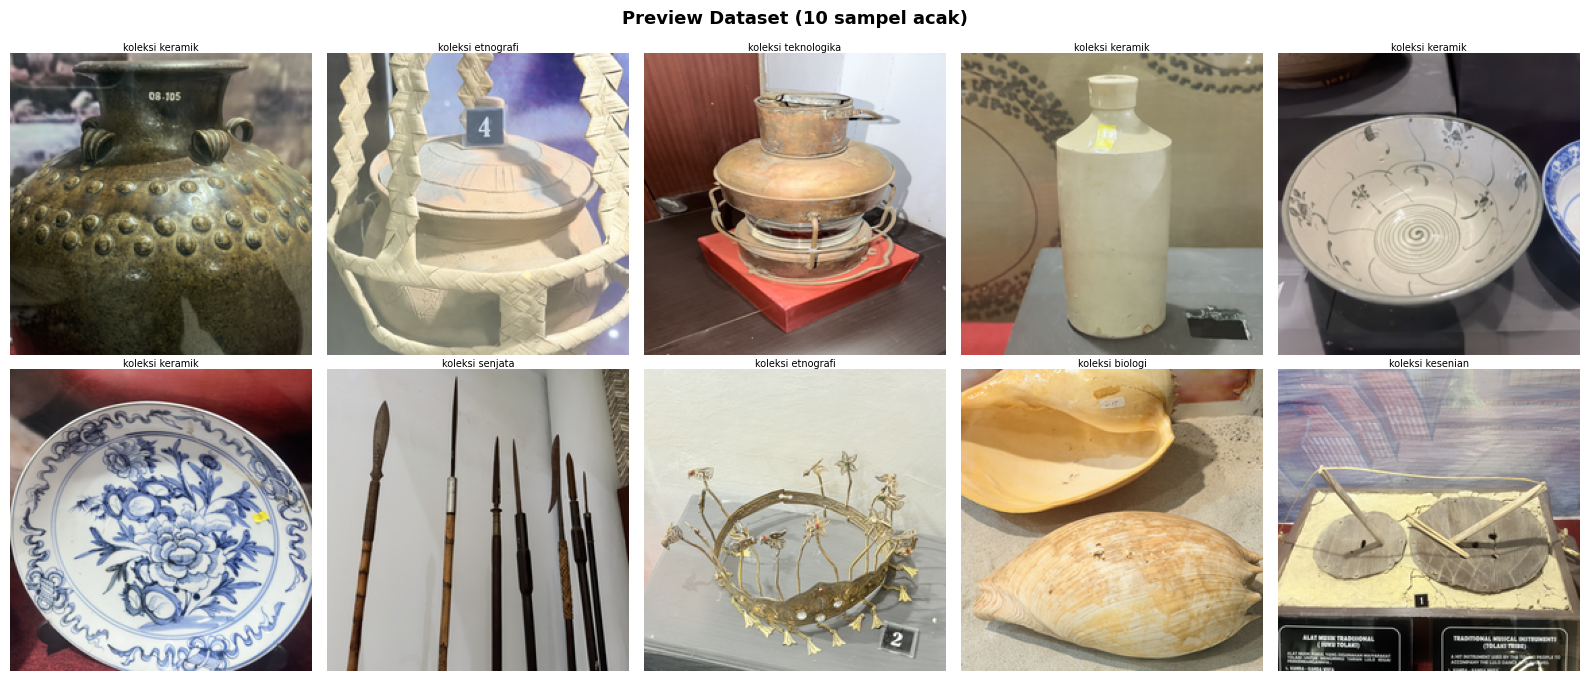

In [3]:
# ============================================================
# CELL 3: LOAD DATASET
# Ground truth label = nama folder (kategori museum)
# Preprocessing: HEIC-aware load → resize 224x224 → EfficientNet preprocess
# ============================================================

def load_image_rgb(path):
    """Baca gambar (HEIC atau standar) → numpy RGB uint8."""
    ext = os.path.splitext(path)[1].lower()
    if ext == '.heic':
        return np.array(Image.open(path).convert('RGB'), dtype=np.uint8)
    else:
        import cv2
        img = cv2.imread(path)
        if img is None: raise ValueError(f'Gagal baca: {path}')
        return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


def load_dataset(dataset_path, img_size=224, valid_ext=('.heic', '.jpg', '.png')):
    all_paths, all_folders = [], []
    for root, _, files in os.walk(dataset_path):
        if any(skip in root for skip in ['hasil_', '.ipynb']):
            continue
        folder = os.path.basename(root)
        for f in sorted(files):
            if f.lower().endswith(valid_ext) and not f.startswith('.'):
                all_paths.append(os.path.join(root, f))
                all_folders.append(folder)

    le = LabelEncoder()
    le.fit(all_folders)
    class_names = list(le.classes_)

    print(f'Total file   : {len(all_paths)}')
    print(f'Kategori     : {len(class_names)}')
    for i, c in enumerate(class_names):
        n = all_folders.count(c)
        print(f'  [{i:02d}] {c:<32} {n:>3} gambar')

    images, paths_ok, folders_ok = [], [], []
    for path, folder in tqdm(zip(all_paths, all_folders),
                             total=len(all_paths), desc='Loading'):
        try:
            img = load_image_rgb(path)
            img = np.array(Image.fromarray(img).resize(
                (img_size, img_size), Image.LANCZOS), dtype=np.float32)
            images.append(img)
            paths_ok.append(path)
            folders_ok.append(folder)
        except Exception as e:
            print(f'[SKIP] {os.path.basename(path)}: {e}')

    images    = np.array(images, dtype='float32')
    gt_labels = le.transform(folders_ok).astype(int)

    print(f'\nBerhasil dimuat : {len(images)} gambar')
    print(f'Shape           : {images.shape}')
    return images, paths_ok, gt_labels, folders_ok, class_names


images, image_paths, gt_labels, gt_names, class_names = load_dataset(
    CONFIG['dataset_path'], CONFIG['img_size'], CONFIG['valid_ext']
)

# Preview 10 sampel acak
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for i, ax in enumerate(axes.flatten()):
    idx = np.random.randint(len(images))
    ax.imshow(images[idx].astype(np.uint8))
    ax.set_title(gt_names[idx], fontsize=7, pad=2)
    ax.axis('off')
plt.suptitle('Preview Dataset (10 sampel acak)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_root'], 'grafik', '00_preview.png'),
            dpi=150, bbox_inches='tight')
plt.show()


## Cell 4 — Ekstraksi Fitur via EfficientNetB0 (Pretrained ImageNet)
> Model **tidak dilatih ulang** — hanya digunakan sebagai feature extractor.
> Output: vektor 1280-dimensi per gambar, kaya fitur semantik.

In [4]:
# ============================================================
# CELL 4: FEATURE EXTRACTION — EfficientNetB0 Pretrained
# Model frozen (semua bobot dari ImageNet, tidak ada training)
# Output per gambar: vektor 1280-dim (Global Average Pooling)
# ============================================================

print(f'Memuat {CONFIG["backbone"]} pretrained ImageNet...')

base_model = EfficientNetB0(
    include_top=False,      # Buang classification head
    weights='imagenet',     # Load bobot pretrained
    pooling=CONFIG['pooling'],  # Global Average Pooling → 1280-dim
    input_shape=(CONFIG['img_size'], CONFIG['img_size'], 3)
)
base_model.trainable = False  # Freeze semua layer

print(f'Model loaded: {base_model.name}')
print(f'Output shape: {base_model.output_shape}')
print(f'Parameter   : {base_model.count_params():,} (semua frozen)')

# Preprocessing sesuai EfficientNet (scale pixel ke [-1, 1])
images_preprocessed = preprocess_input(images.copy())

# Ekstraksi fitur batch-by-batch
print(f'\nMengekstraksi fitur dari {len(images)} gambar...')
t0 = time.time()

features_raw = base_model.predict(
    images_preprocessed,
    batch_size=CONFIG['batch_size'],
    verbose=1
)

elapsed = time.time() - t0
print(f'\nEkstraksi selesai: {elapsed:.1f} detik')
print(f'Shape features   : {features_raw.shape}')  # (N, 1280)
print(f'Min / Max        : {features_raw.min():.3f} / {features_raw.max():.3f}')

# L2 Normalization (cosine similarity lebih baik dari Euclidean untuk CNN features)
features_l2 = normalize(features_raw, norm='l2')
print(f'Setelah L2-norm  : min={features_l2.min():.4f}, max={features_l2.max():.4f}')

np.save(os.path.join(CONFIG['output_root'], 'features_raw.npy'), features_raw)
np.save(os.path.join(CONFIG['output_root'], 'features_l2.npy'), features_l2)
print('Fitur tersimpan.')


Memuat EfficientNetB0 pretrained ImageNet...


2026-05-29 02:12:35.098907: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M5
2026-05-29 02:12:35.098940: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-05-29 02:12:35.098943: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
2026-05-29 02:12:35.098970: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-29 02:12:35.098983: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model loaded: efficientnetb0
Output shape: (None, 1280)
Parameter   : 4,049,571 (semua frozen)

Mengekstraksi fitur dari 593 gambar...


2026-05-29 02:12:36.908642: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 106ms/step

Ekstraksi selesai: 6.5 detik
Shape features   : (593, 1280)
Min / Max        : -0.266 / 4.572
Setelah L2-norm  : min=-0.0296, max=0.3477
Fitur tersimpan.


## Cell 5 — Reduksi Dimensi: PCA → UMAP
> 1280D → PCA 128D → UMAP 50D
> UMAP mempertahankan struktur lokal DAN global lebih baik dari PCA/t-SNE.

PCA: 1280D → 128D...
  Variance explained by 128 PCs: 84.7%

UMAP: 128D → 50D...
UMAP(angular_rp_forest=True, metric='cosine', n_components=50, n_jobs=1, random_state=42, verbose=True)
Fri May 29 02:12:43 2026 Construct fuzzy simplicial set
Fri May 29 02:12:43 2026 Finding Nearest Neighbors
Fri May 29 02:12:44 2026 Finished Nearest Neighbor Search
Fri May 29 02:12:46 2026 Construct embedding


Epochs completed:  21%| ██         105/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs


Epochs completed:  82%| ████████▏  412/500 [00:00]

	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs


Epochs completed: 100%| ██████████ 500/500 [00:00]


Fri May 29 02:12:46 2026 Finished embedding

Shape setelah reduksi: (593, 50)
Metode reduksi       : PCA128D + UMAP50D
Features final tersimpan.


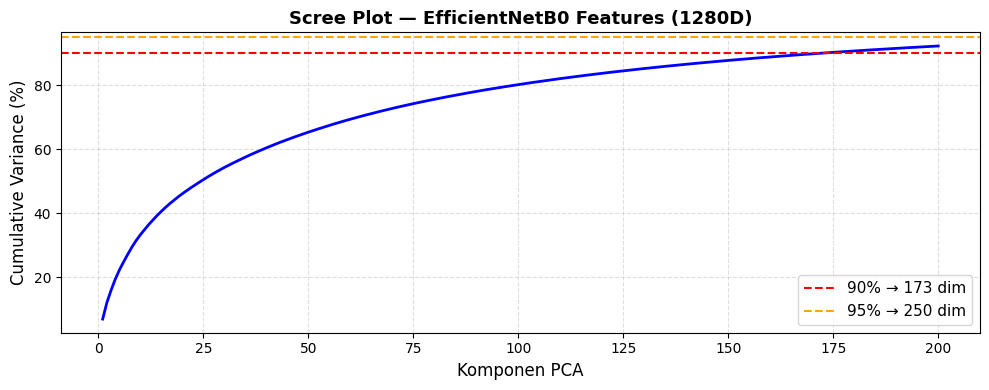

In [5]:
# ============================================================
# CELL 5: DIMENSIONALITY REDUCTION
# Alur: L2-features (1280D) → PCA (128D) → UMAP (50D)
# PCA dulu untuk mempercepat UMAP + mengurangi noise
# ============================================================

# ── Step 1: PCA ─────────────────────────────────────────────
print(f'PCA: 1280D → {CONFIG["pca_dim"]}D...')
pca = PCA(n_components=CONFIG['pca_dim'], random_state=SEED)
features_pca = pca.fit_transform(features_l2)
var_explained = pca.explained_variance_ratio_.sum() * 100
print(f'  Variance explained by {CONFIG["pca_dim"]} PCs: {var_explained:.1f}%')

# ── Step 2: UMAP (jika tersedia) ────────────────────────────
if UMAP_AVAILABLE:
    print(f'\nUMAP: {CONFIG["pca_dim"]}D → {CONFIG["umap_dim"]}D...')
    reducer = umap.UMAP(
        n_components=CONFIG['umap_dim'],
        n_neighbors=CONFIG['umap_n_neighbors'],
        min_dist=CONFIG['umap_min_dist'],
        metric='cosine',
        random_state=SEED,
        verbose=True
    )
    features_reduced = reducer.fit_transform(features_pca)
    REDUCTION_METHOD = f'PCA{CONFIG["pca_dim"]}D + UMAP{CONFIG["umap_dim"]}D'
else:
    print('\n[Fallback] Menggunakan PCA saja (UMAP tidak tersedia)')
    features_reduced = features_pca
    REDUCTION_METHOD = f'PCA{CONFIG["pca_dim"]}D'

print(f'\nShape setelah reduksi: {features_reduced.shape}')
print(f'Metode reduksi       : {REDUCTION_METHOD}')

# Normalisasi ulang setelah reduksi
features_final = normalize(features_reduced, norm='l2')

np.save(os.path.join(CONFIG['output_root'], 'features_final.npy'), features_final)
print('Features final tersimpan.')

# ── Scree Plot PCA ──────────────────────────────────────────
pca_full = PCA(random_state=SEED).fit(features_l2)
cumvar = np.cumsum(pca_full.explained_variance_ratio_) * 100
n90 = int(np.argmax(cumvar >= 90)) + 1
n95 = int(np.argmax(cumvar >= 95)) + 1

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, min(201, len(cumvar)+1)), cumvar[:200], 'b-', lw=2)
ax.axhline(90, color='red', ls='--', label=f'90% → {n90} dim')
ax.axhline(95, color='orange', ls='--', label=f'95% → {n95} dim')
ax.set_xlabel('Komponen PCA', fontsize=12)
ax.set_ylabel('Cumulative Variance (%)', fontsize=12)
ax.set_title(f'Scree Plot — EfficientNetB0 Features (1280D)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.grid(True, ls='--', alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_root'], 'grafik', '01_scree_pca.png'), dpi=150, bbox_inches='tight')
plt.show()


## Cell 6 — Cari K Optimal (Silhouette + Elbow)
> Sekarang dijalankan di atas fitur EfficientNet yang jauh lebih diskriminatif.

Mencari K optimal...


K search:   7%|▋         | 1/14 [00:00<00:01,  6.98it/s]

  K= 2 | Silhouette=0.6338 | Inertia=6.6


K search:  21%|██▏       | 3/14 [00:00<00:00, 11.13it/s]

  K= 3 | Silhouette=0.5158 | Inertia=3.3
  K= 4 | Silhouette=0.4930 | Inertia=2.6
  K= 5 | Silhouette=0.5257 | Inertia=1.9


...

  K=11 | Silhouette=0.5362 | Inertia=0.5
  K=12 | Silhouette=0.5572 | Inertia=0.4


K search:  93%|█████████▎| 13/14 [00:01<00:00,  9.25it/s]

  K=13 | Silhouette=0.5590 | Inertia=0.4
  K=14 | Silhouette=0.5638 | Inertia=0.3


K search: 100%|██████████| 14/14 [00:01<00:00,  9.68it/s]


  K=15 | Silhouette=0.5822 | Inertia=0.3

K Optimal (Silhouette tertinggi) : K = 2 (0.6338)


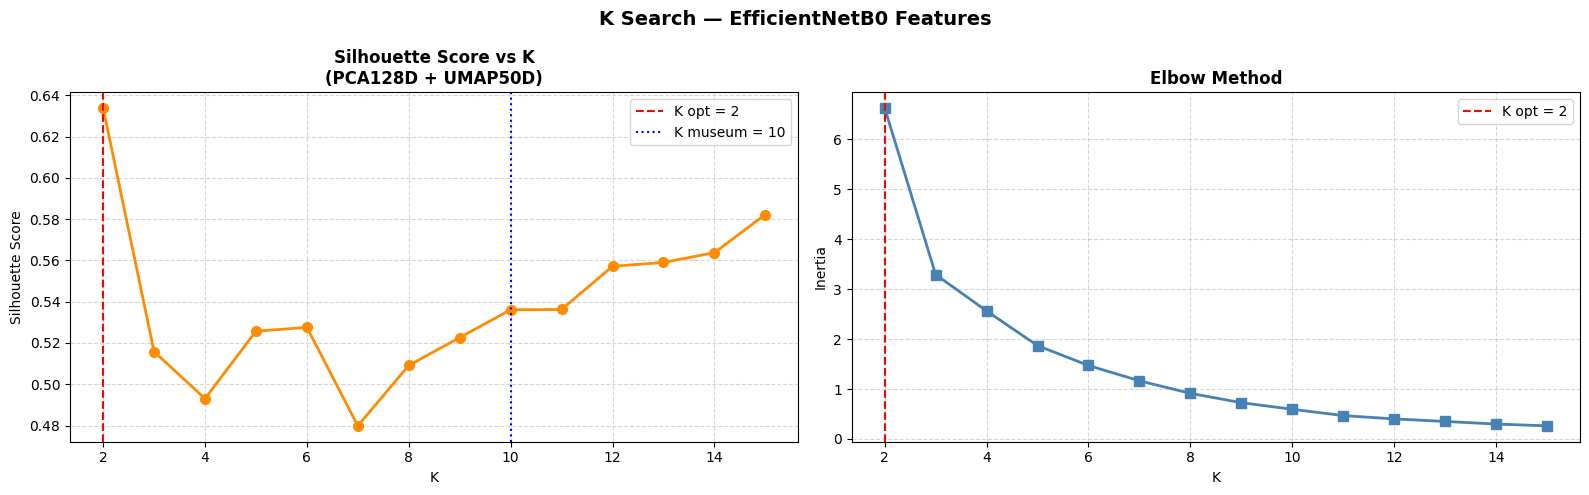

In [6]:
# ============================================================
# CELL 6: K SEARCH — Silhouette + Elbow
# ============================================================

print('Mencari K optimal...')
sil_scores, inertias = [], []
k_range = CONFIG['k_range']

for k in tqdm(k_range, desc='K search'):
    km = KMeans(n_clusters=k, n_init=20, random_state=SEED, init='k-means++')
    lbl = km.fit_predict(features_final)
    sil = silhouette_score(features_final, lbl) if len(np.unique(lbl)) > 1 else -1
    sil_scores.append(sil)
    inertias.append(km.inertia_)
    print(f'  K={k:2d} | Silhouette={sil:.4f} | Inertia={km.inertia_:.1f}')

best_k_idx = int(np.argmax(sil_scores))
K_OPTIMAL  = k_range[best_k_idx]
print(f'\nK Optimal (Silhouette tertinggi) : K = {K_OPTIMAL} ({sil_scores[best_k_idx]:.4f})')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.plot(k_range, sil_scores, 'o-', color='darkorange', lw=2, ms=7)
ax.axvline(K_OPTIMAL, color='red', ls='--', lw=1.5, label=f'K opt = {K_OPTIMAL}')
ax.axvline(CONFIG['k_fixed'], color='blue', ls=':', lw=1.5, label=f'K museum = {CONFIG["k_fixed"]}')
sil_k10 = sil_scores[k_range.index(CONFIG['k_fixed'])] if CONFIG['k_fixed'] in k_range else None
ax.set_title(f'Silhouette Score vs K\n({REDUCTION_METHOD})', fontsize=12, fontweight='bold')
ax.set_xlabel('K'); ax.set_ylabel('Silhouette Score')
ax.legend(); ax.grid(True, ls='--', alpha=0.5)

ax = axes[1]
ax.plot(k_range, inertias, 's-', color='steelblue', lw=2, ms=7)
ax.axvline(K_OPTIMAL, color='red', ls='--', lw=1.5, label=f'K opt = {K_OPTIMAL}')
ax.set_title('Elbow Method', fontsize=12, fontweight='bold')
ax.set_xlabel('K'); ax.set_ylabel('Inertia')
ax.legend(); ax.grid(True, ls='--', alpha=0.5)

plt.suptitle(f'K Search — EfficientNetB0 Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_root'], 'grafik', '02_k_search.png'), dpi=200, bbox_inches='tight')
plt.show()

# Simpan
with open(os.path.join(CONFIG['output_root'], 'k_search.json'), 'w') as f:
    json.dump({'k_range': k_range, 'silhouette': sil_scores,
               'inertia': inertias, 'k_optimal': K_OPTIMAL}, f, indent=2)


## Cell 7 — Clustering: K-Means (K optimal + K=10)

In [7]:
# ============================================================
# CELL 7: K-MEANS (n_init=50, k-means++)
# Dijalankan untuk K_OPTIMAL dan K_FIXED=10
# ============================================================

def run_kmeans(features, n_clusters, n_init=50, seed=42, label=''):
    print(f'K-Means K={n_clusters} (n_init={n_init})...')
    km = KMeans(n_clusters=n_clusters, n_init=n_init,
               max_iter=1000, init='k-means++', random_state=seed)
    labels = km.fit_predict(features)
    sil = silhouette_score(features, labels)
    dbi = davies_bouldin_score(features, labels)
    chi = calinski_harabasz_score(features, labels)
    print(f'  Silhouette : {sil:.4f}')
    print(f'  DBI        : {dbi:.4f}')
    print(f'  CHI        : {chi:.1f}')
    return labels, km.cluster_centers_, {'sil': sil, 'dbi': dbi, 'chi': chi}


print('=== K-Means K=OPTIMAL ===')
km_labels_opt, km_centers_opt, km_scores_opt = run_kmeans(
    features_final, K_OPTIMAL, CONFIG['kmeans_n_init'], SEED)

print('\n=== K-Means K=10 (museum) ===')
km_labels_10, km_centers_10, km_scores_10 = run_kmeans(
    features_final, CONFIG['k_fixed'], CONFIG['kmeans_n_init'], SEED)

# Gunakan K=10 sebagai label utama K-Means
km_labels   = km_labels_10
km_scores   = km_scores_10
N_CLUSTERS  = CONFIG['k_fixed']

np.save(os.path.join(CONFIG['output_root'], 'km_labels.npy'), km_labels)
print(f'\nK-Means selesai. K yang dipakai: {N_CLUSTERS}')
print('Distribusi cluster K-Means (K=10):')
for cl, cnt in sorted(Counter(km_labels).items()):
    print(f'  C{cl:02d}: {cnt} gambar  {"█" * (cnt // 4)}')


=== K-Means K=OPTIMAL ===
K-Means K=2 (n_init=50)...
  Silhouette : 0.6338
  DBI        : 0.3247
  CHI        : 340.1

=== K-Means K=10 (museum) ===
K-Means K=10 (n_init=50)...
  Silhouette : 0.5329
  DBI        : 0.5886
  CHI        : 1074.5

K-Means selesai. K yang dipakai: 10
Distribusi cluster K-Means (K=10):
  C00: 65 gambar  ████████████████
  C01: 90 gambar  ██████████████████████
  C02: 35 gambar  ████████
  C03: 82 gambar  ████████████████████
  C04: 130 gambar  ████████████████████████████████
  C05: 9 gambar  ██
  C06: 30 gambar  ███████
  C07: 85 gambar  █████████████████████
  C08: 55 gambar  █████████████
  C09: 12 gambar  ███


## Cell 8 — Clustering: Gaussian Mixture Model (GMM)
> GMM lebih fleksibel dari K-Means: cluster bisa berbentuk ellips,
> dan tiap gambar mendapat probabilitas keanggotaan ke setiap cluster (*soft assignment*).

In [8]:
# ============================================================
# CELL 8: GAUSSIAN MIXTURE MODEL (GMM)
# covariance_type='full': setiap cluster punya covariance matrix sendiri
# ============================================================

print(f'GMM K={N_CLUSTERS} (n_init={CONFIG["gmm_n_init"]})...')

gmm = GaussianMixture(
    n_components=N_CLUSTERS,
    covariance_type='full',
    n_init=CONFIG['gmm_n_init'],
    max_iter=200,
    random_state=SEED,
    verbose=1
)
gmm.fit(features_final)
gmm_labels    = gmm.predict(features_final)
gmm_proba     = gmm.predict_proba(features_final)  # soft assignment (N, K)

# Evaluasi
gmm_sil = silhouette_score(features_final, gmm_labels)
gmm_dbi = davies_bouldin_score(features_final, gmm_labels)
gmm_chi = calinski_harabasz_score(features_final, gmm_labels)
gmm_bic = gmm.bic(features_final)
gmm_aic = gmm.aic(features_final)

print(f'\nGMM Selesai:')
print(f'  Silhouette : {gmm_sil:.4f}')
print(f'  DBI        : {gmm_dbi:.4f}')
print(f'  CHI        : {gmm_chi:.1f}')
print(f'  BIC        : {gmm_bic:.1f}  (lebih rendah = lebih baik)')
print(f'  AIC        : {gmm_aic:.1f}  (lebih rendah = lebih baik)')

print('\nDistribusi cluster GMM:')
for cl, cnt in sorted(Counter(gmm_labels).items()):
    mean_conf = gmm_proba[gmm_labels == cl, cl].mean()
    print(f'  C{cl:02d}: {cnt:>3} gambar | confidence rata-rata: {mean_conf:.3f}')

gmm_scores = {'sil': gmm_sil, 'dbi': gmm_dbi, 'chi': gmm_chi,
              'bic': gmm_bic, 'aic': gmm_aic}
np.save(os.path.join(CONFIG['output_root'], 'gmm_labels.npy'), gmm_labels)
np.save(os.path.join(CONFIG['output_root'], 'gmm_proba.npy'), gmm_proba)


GMM K=10 (n_init=5)...
Initialization 0
Initialization converged.
Initialization 1
Initialization converged.
Initialization 2
  Iteration 10
Initialization converged.
Initialization 3
Initialization converged.
Initialization 4
Initialization converged.

GMM Selesai:
  Silhouette : 0.5157
  DBI        : 0.6522
  CHI        : 1041.7
  BIC        : -249840.0  (lebih rendah = lebih baik)
  AIC        : -307983.3  (lebih rendah = lebih baik)

Distribusi cluster GMM:
  C00:  61 gambar | confidence rata-rata: 1.000
  C01:  96 gambar | confidence rata-rata: 0.995
  C02:  35 gambar | confidence rata-rata: 1.000
  C03: 126 gambar | confidence rata-rata: 0.998
  C04:  90 gambar | confidence rata-rata: 0.999
  C05:  65 gambar | confidence rata-rata: 1.000
  C06:   9 gambar | confidence rata-rata: 1.000
  C07:  30 gambar | confidence rata-rata: 1.000
  C08:  69 gambar | confidence rata-rata: 0.982
  C09:  12 gambar | confidence rata-rata: 1.000


## Cell 9 — Clustering: HDBSCAN (Density-Based, K Otomatis)
> HDBSCAN menentukan jumlah cluster secara otomatis berdasarkan kepadatan data.
> Gambar yang 'aneh'/outlier akan diberi label `-1` (noise).

In [9]:
# ============================================================
# CELL 9: HDBSCAN
# Tidak perlu tentukan K — jumlah cluster ditentukan otomatis
# ============================================================

if HDBSCAN_AVAILABLE:
    print('Menjalankan HDBSCAN...')
    hdb = hdbscan.HDBSCAN(
        min_cluster_size=CONFIG['hdbscan_min_cluster_size'],
        min_samples=3,
        metric='euclidean',
        cluster_selection_method='eom'
    )
    hdb_labels_raw = hdb.fit_predict(features_final)

    n_clusters_found = len(set(hdb_labels_raw)) - (1 if -1 in hdb_labels_raw else 0)
    n_noise = np.sum(hdb_labels_raw == -1)
    print(f'  Cluster ditemukan : {n_clusters_found}')
    print(f'  Noise/outlier     : {n_noise} gambar ({n_noise/len(hdb_labels_raw)*100:.1f}%)')

    # Evaluasi hanya pada non-noise
    mask_valid = hdb_labels_raw != -1
    if mask_valid.sum() > 0 and n_clusters_found > 1:
        hdb_sil = silhouette_score(features_final[mask_valid], hdb_labels_raw[mask_valid])
        hdb_dbi = davies_bouldin_score(features_final[mask_valid], hdb_labels_raw[mask_valid])
        print(f'  Silhouette (non-noise) : {hdb_sil:.4f}')
        print(f'  DBI (non-noise)        : {hdb_dbi:.4f}')
        hdb_scores = {'sil': hdb_sil, 'dbi': hdb_dbi, 'n_clusters': n_clusters_found, 'n_noise': int(n_noise)}
    else:
        print('  [WARN] Terlalu banyak noise atau hanya 1 cluster.')
        hdb_sil, hdb_dbi = None, None
        hdb_scores = {'sil': None, 'dbi': None, 'n_clusters': n_clusters_found, 'n_noise': int(n_noise)}

    print('\nDistribusi cluster HDBSCAN:')
    for cl, cnt in sorted(Counter(hdb_labels_raw).items()):
        label_str = 'NOISE' if cl == -1 else f'C{cl:02d}'
        print(f'  {label_str}: {cnt:>3} gambar')

    hdb_labels = hdb_labels_raw
    np.save(os.path.join(CONFIG['output_root'], 'hdb_labels.npy'), hdb_labels)

else:
    print('[SKIP] HDBSCAN tidak tersedia. Install: pip install hdbscan')
    hdb_labels = None
    hdb_scores = {'sil': None, 'dbi': None, 'n_clusters': 0, 'n_noise': 0}


Menjalankan HDBSCAN...
  Cluster ditemukan : 29
  Noise/outlier     : 29 gambar (4.9%)
  Silhouette (non-noise) : 0.6225
  DBI (non-noise)        : 0.4871

Distribusi cluster HDBSCAN:
  NOISE:  29 gambar
  C00:  35 gambar
  C01:   9 gambar
  C02:  12 gambar
  C03:  13 gambar
  C04:  16 gambar
  C05:  20 gambar
  C06:  45 gambar
  C07:  15 gambar
  C08:  12 gambar
  C09:  13 gambar
  C10:  52 gambar
  C11:  11 gambar
  C12:  12 gambar
  C13:   8 gambar
  C14:  14 gambar
  C15:  48 gambar
  C16:   8 gambar
  C17:  15 gambar
  C18:  22 gambar
  C19:   9 gambar
  C20:  37 gambar
  C21:  17 gambar
  C22:  11 gambar
  C23:  21 gambar
  C24:  36 gambar
  C25:  11 gambar
  C26:   8 gambar
  C27:  24 gambar
  C28:  10 gambar


## Cell 10 — Perbandingan Semua Metode

Metode                 Silhouette        DBI          CHI     K
---------------------------------------------------------------
K-Means (K=opt)            0.6338     0.3247        340.1     2
K-Means (K=10)             0.5329     0.5886       1074.5    10
GMM (K=10)                 0.5157     0.6522       1041.7    10
HDBSCAN (K=auto)           0.6225     0.4871            -    29


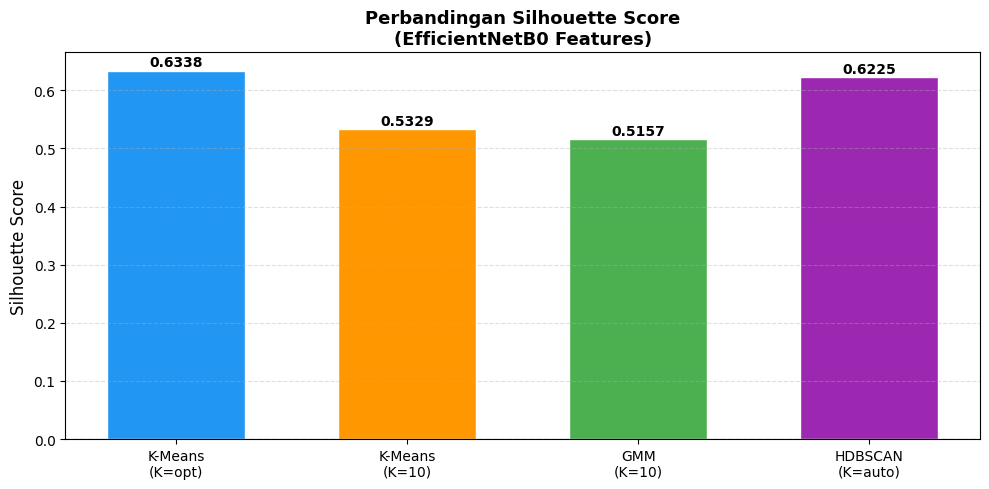


→ Metode terbaik: K-Means (K=opt) (Silhouette = 0.6338)


In [10]:
# ============================================================
# CELL 10: PERBANDINGAN K-MEANS vs GMM vs HDBSCAN
# ============================================================

methods = [
    ('K-Means\n(K=opt)', km_scores_opt['sil'], km_scores_opt['dbi'], km_scores_opt['chi'], K_OPTIMAL),
    ('K-Means\n(K=10)',  km_scores_10['sil'],  km_scores_10['dbi'],  km_scores_10['chi'],  10),
    ('GMM\n(K=10)',       gmm_scores['sil'],    gmm_scores['dbi'],    gmm_scores['chi'],    10),
]
if HDBSCAN_AVAILABLE and hdb_scores['sil'] is not None:
    methods.append(('HDBSCAN\n(K=auto)', hdb_scores['sil'], hdb_scores['dbi'], None, hdb_scores['n_clusters']))

print(f'{"Metode":<20} {"Silhouette":>12} {"DBI":>10} {"CHI":>12} {"K":>5}')
print('-' * 63)
for name, sil, dbi, chi, k in methods:
    name_str = name.replace('\n', ' ')
    chi_str  = f'{chi:12.1f}' if chi else '           -'
    print(f'{name_str:<20} {sil:12.4f} {dbi:10.4f} {chi_str} {k:5d}')

# Bar chart Silhouette
names_plot = [m[0] for m in methods]
sils_plot  = [m[1] for m in methods]
colors     = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0'][:len(methods)]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(len(methods)), sils_plot, color=colors, edgecolor='white', width=0.6)
for bar, v in zip(bars, sils_plot):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{v:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_xticks(range(len(methods)))
ax.set_xticklabels(names_plot, fontsize=10)
ax.set_ylabel('Silhouette Score', fontsize=12)
ax.set_title('Perbandingan Silhouette Score\n(EfficientNetB0 Features)',
             fontsize=13, fontweight='bold')
ax.axhline(0, color='gray', ls='--', lw=1, alpha=0.5)
ax.grid(True, axis='y', ls='--', alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_root'], 'grafik', '03_metode_comparison.png'),
            dpi=200, bbox_inches='tight')
plt.show()

# Tentukan metode terbaik
best_idx    = int(np.argmax(sils_plot))
BEST_METHOD = names_plot[best_idx].replace('\n', ' ')
BEST_SIL    = sils_plot[best_idx]
print(f'\n→ Metode terbaik: {BEST_METHOD} (Silhouette = {BEST_SIL:.4f})')


## Cell 11 — Visualisasi t-SNE 2D (K-Means | GMM | Ground Truth)

Menjalankan t-SNE...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 593 samples in 0.000s...
[t-SNE] Computed neighbors for 593 samples in 0.037s...
[t-SNE] Computed conditional probabilities for sample 593 / 593
[t-SNE] Mean sigma: 0.017667
[t-SNE] KL divergence after 250 iterations with early exaggeration: 45.430408
[t-SNE] KL divergence after 1000 iterations: 0.132055
t-SNE selesai: (593, 2)


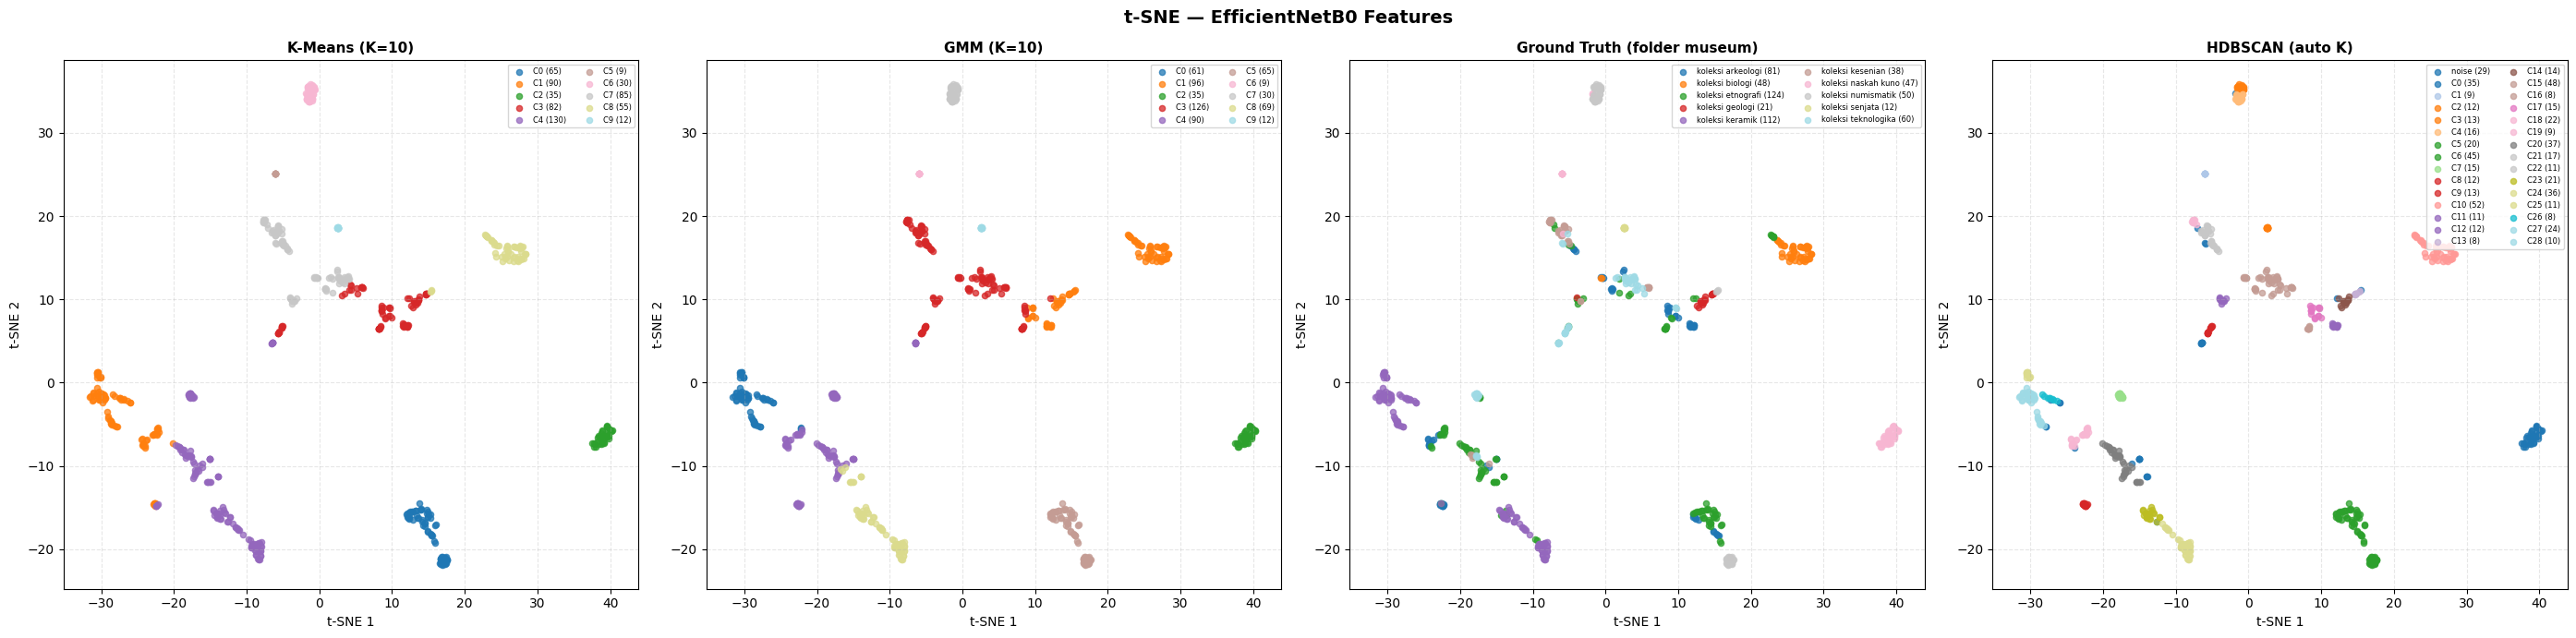

In [11]:
# ============================================================
# CELL 11: t-SNE VISUALIZATION
# ============================================================

from sklearn.manifold import TSNE

print('Menjalankan t-SNE...')
tsne_reducer = TSNE(
    n_components=2,
    perplexity=CONFIG['tsne_perplexity'],
    max_iter=1000,
    random_state=SEED,
    verbose=1
)
# Gunakan PCA 50D sebagai input t-SNE (lebih cepat)
pca_50 = PCA(n_components=min(50, features_final.shape[1]), random_state=SEED)
feat_2d = tsne_reducer.fit_transform(pca_50.fit_transform(features_final))
np.save(os.path.join(CONFIG['output_root'], 'tsne_2d.npy'), feat_2d)
print(f't-SNE selesai: {feat_2d.shape}')

# Plot 3 panel
n_panels = 3 if not HDBSCAN_AVAILABLE or hdb_labels is None else 4
fig, axes = plt.subplots(1, n_panels, figsize=(7 * n_panels, 7))
if n_panels == 3: axes = list(axes)

configs_plot = [
    (km_labels,  N_CLUSTERS,        'K-Means (K=10)'),
    (gmm_labels, N_CLUSTERS,        'GMM (K=10)'),
    (gt_labels,  len(class_names),  'Ground Truth (folder museum)'),
]
if HDBSCAN_AVAILABLE and hdb_labels is not None:
    n_hdb = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
    configs_plot.append((hdb_labels, n_hdb + 1, 'HDBSCAN (auto K)'))

for ax, (lbl_t, n_t, title_t) in zip(axes, configs_plot):
    unique_lbl = sorted(set(lbl_t))
    cmap_fn = plt.cm.get_cmap('tab20', len(unique_lbl))
    for i, cl in enumerate(unique_lbl):
        mask = lbl_t == cl
        if title_t.startswith('Ground'):
            lbl_str = class_names[cl] if cl < len(class_names) else f'C{cl}'
        elif cl == -1:
            lbl_str = 'noise'
        else:
            lbl_str = f'C{cl}'
        ax.scatter(feat_2d[mask, 0], feat_2d[mask, 1],
                   s=20, alpha=0.75, color=cmap_fn(i),
                   label=f'{lbl_str} ({mask.sum()})')
    ax.set_title(title_t, fontsize=11, fontweight='bold')
    ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
    ax.legend(fontsize=6, ncol=2, loc='upper right')
    ax.grid(True, ls='--', alpha=0.3)

plt.suptitle('t-SNE — EfficientNetB0 Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_root'], 'grafik', '04_tsne.png'),
            dpi=200, bbox_inches='tight')
plt.show()


## Cell 12 — Silhouette Plot Per-Sampel (K-Means & GMM)

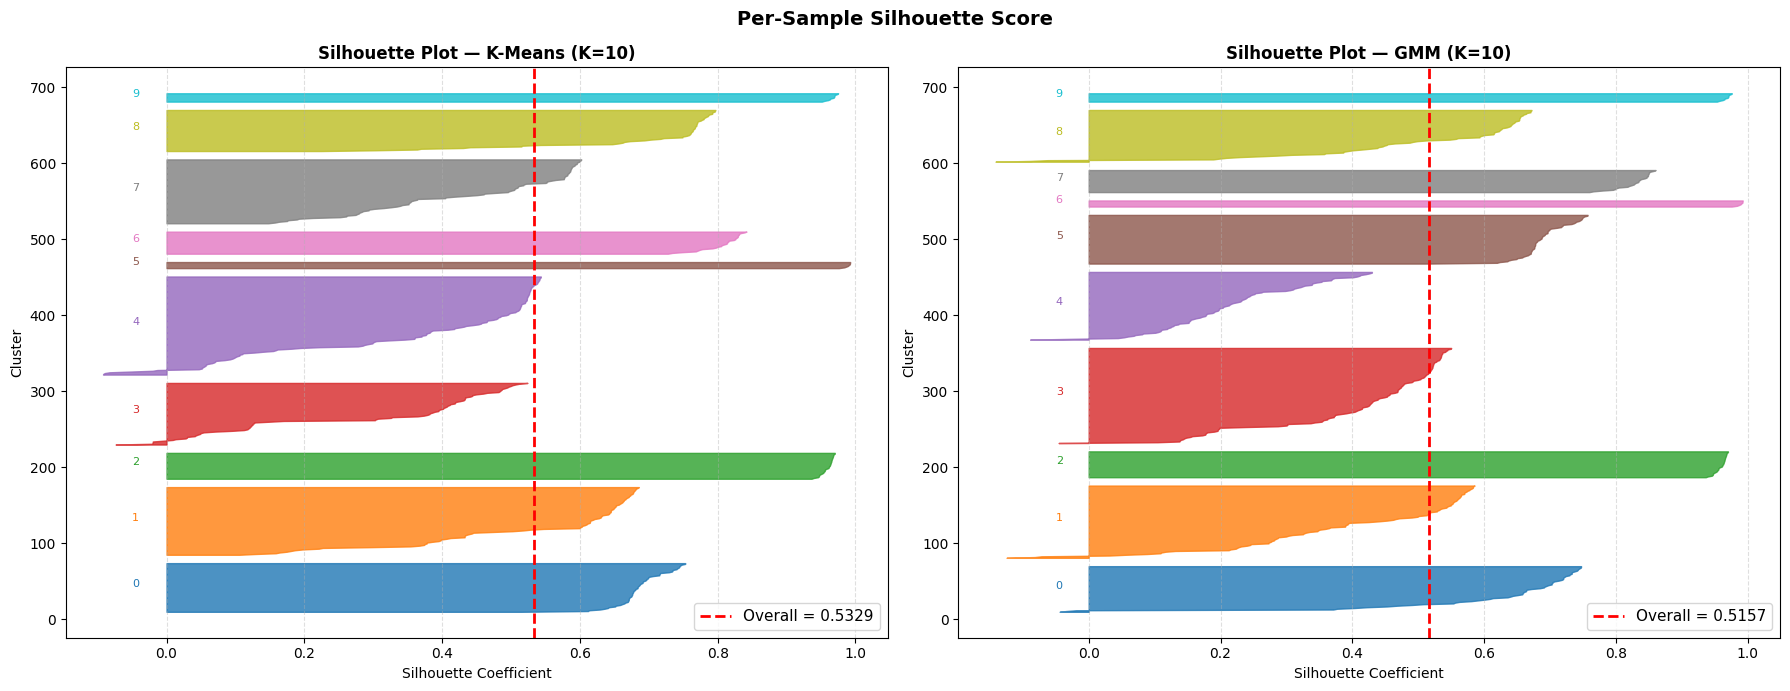

In [12]:
# ============================================================
# CELL 12: SILHOUETTE PER-SAMPEL
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, (lbl_t, title_t, overall_sil) in zip(axes, [
    (km_labels, 'K-Means (K=10)', km_scores_10['sil']),
    (gmm_labels, 'GMM (K=10)',    gmm_scores['sil']),
]):
    sil_smp = silhouette_samples(features_final, lbl_t)
    n_cl    = len(np.unique(lbl_t))
    cmap_fn = plt.cm.get_cmap('tab10', n_cl)
    y_lower = 10
    for cl in range(n_cl):
        sil_cl  = np.sort(sil_smp[lbl_t == cl])
        size_cl = len(sil_cl)
        y_upper = y_lower + size_cl
        color   = cmap_fn(cl)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, sil_cl,
                         facecolor=color, edgecolor=color, alpha=0.8)
        ax.text(-0.05, y_lower + 0.5 * size_cl, str(cl), fontsize=8, color=color)
        y_lower = y_upper + 10
    ax.axvline(overall_sil, color='red', ls='--', lw=2,
               label=f'Overall = {overall_sil:.4f}')
    ax.set_title(f'Silhouette Plot — {title_t}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Silhouette Coefficient'); ax.set_ylabel('Cluster')
    ax.legend(fontsize=11); ax.grid(True, axis='x', ls='--', alpha=0.4)

plt.suptitle('Per-Sample Silhouette Score', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_root'], 'grafik', '05_silhouette_plot.png'),
            dpi=200, bbox_inches='tight')
plt.show()


## Cell 13 — Confusion Matrix vs Ground Truth (Hungarian Algorithm)
> Mengukur seberapa cocok hasil clustering dengan 10 kategori folder museum.

Cluster Accuracy (Hungarian):
  K-Means : 47.89%
  GMM     : 46.04%

Mapping K-Means C→Kategori:
  C00 → koleksi etnografi              (32/65)
  C01 → koleksi keramik                (59/90)
  C02 → koleksi naskah kuno            (35/35)
  C03 → koleksi arkeologi              (22/82)
  C04 → koleksi teknologika            (22/130)
  C05 → koleksi geologi                (0/9)
  C06 → koleksi numismatik             (28/30)
  C07 → koleksi kesenian               (28/85)
  C08 → koleksi biologi                (46/55)
  C09 → koleksi senjata                (12/12)


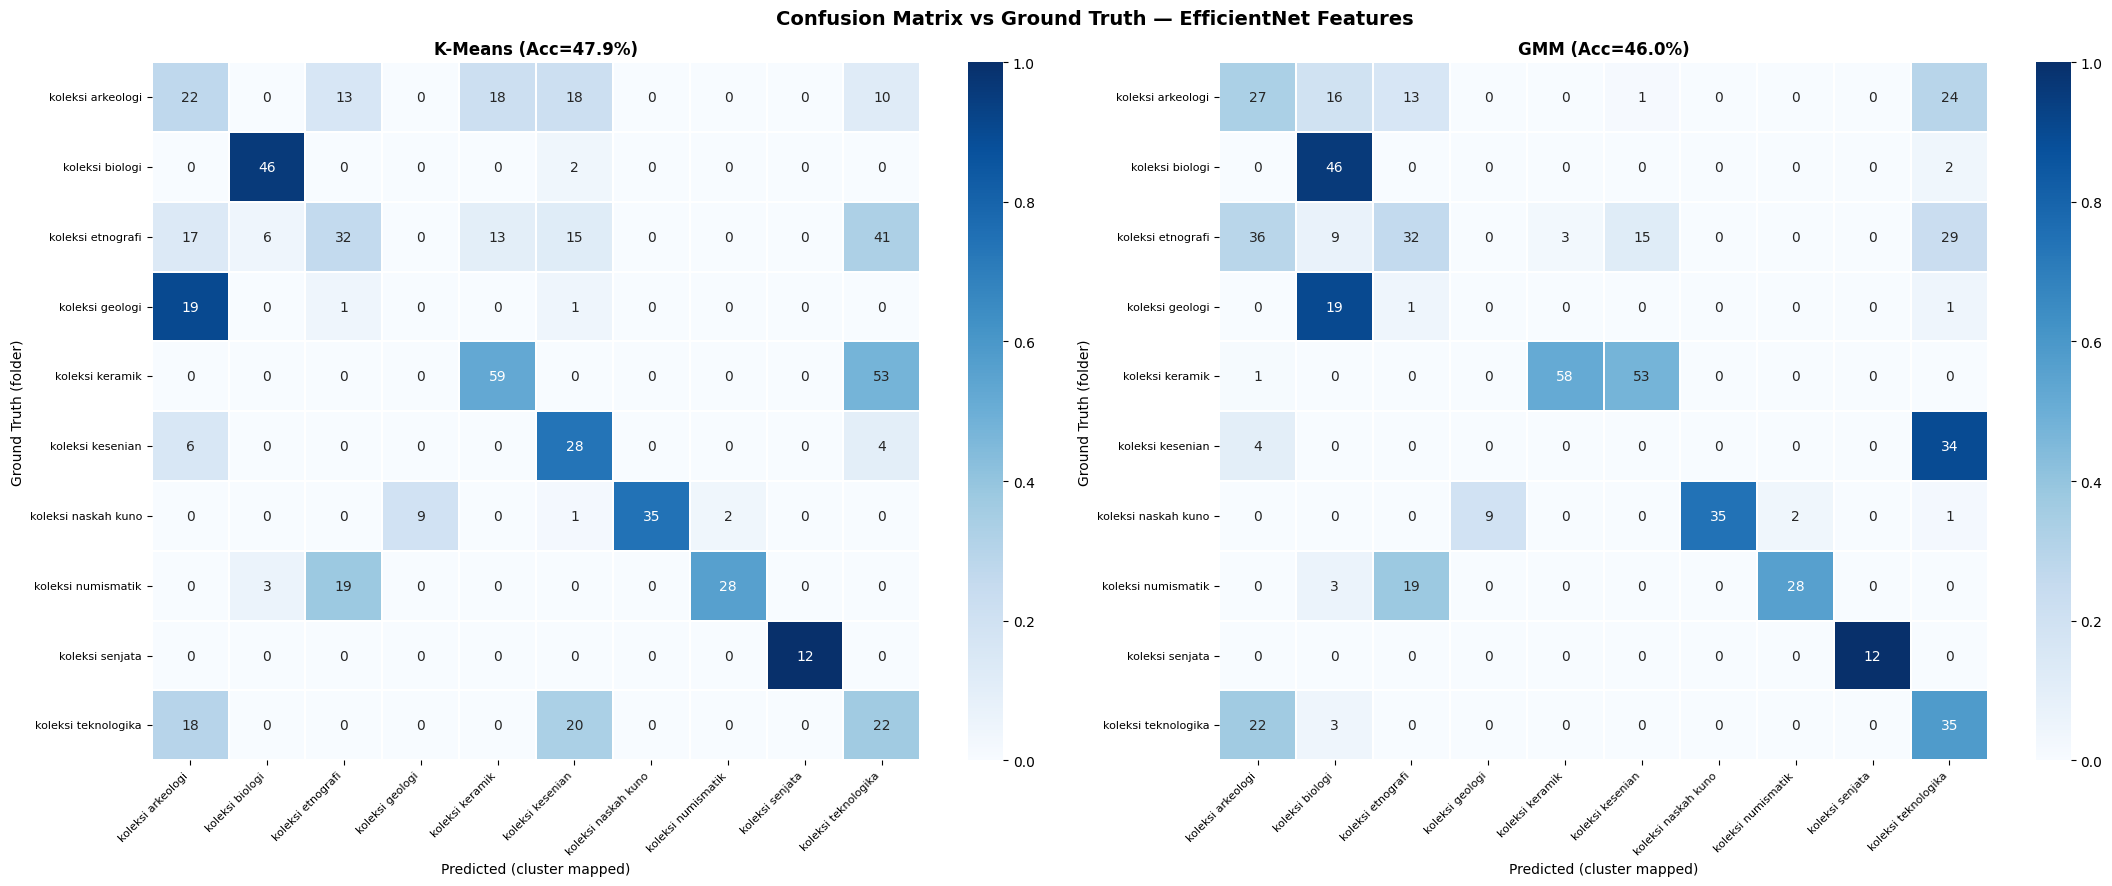

In [13]:
# ============================================================
# CELL 13: CONFUSION MATRIX + HUNGARIAN ALGORITHM
# ============================================================

def cluster_accuracy_hungarian(gt, pred, class_names):
    n_pred    = len(np.unique(pred[pred != -1]))
    n_classes = len(class_names)
    cost = np.zeros((n_pred, n_classes), dtype=int)
    unique_pred = sorted(set(pred[pred != -1]))
    for i, cl in enumerate(unique_pred):
        for j in range(n_classes):
            cost[i, j] = np.sum((pred == cl) & (gt == j))
    row_ind, col_ind = linear_sum_assignment(-cost)
    mapping = {unique_pred[row_ind[i]]: col_ind[i] for i in range(len(row_ind))}
    pred_mapped = np.array([mapping.get(p, -1) for p in pred])
    valid = pred_mapped != -1
    acc   = np.sum(pred_mapped[valid] == gt[valid]) / len(gt)
    return acc, mapping, pred_mapped


acc_km,  map_km,  km_mapped  = cluster_accuracy_hungarian(gt_labels, km_labels, class_names)
acc_gmm, map_gmm, gmm_mapped = cluster_accuracy_hungarian(gt_labels, gmm_labels, class_names)

print(f'Cluster Accuracy (Hungarian):')
print(f'  K-Means : {acc_km*100:.2f}%')
print(f'  GMM     : {acc_gmm*100:.2f}%')

# Mapping detail
print(f'\nMapping K-Means C→Kategori:')
for cl, gt_idx in sorted(map_km.items()):
    n_match = np.sum((km_labels == cl) & (gt_labels == gt_idx))
    n_cl    = np.sum(km_labels == cl)
    print(f'  C{cl:02d} → {class_names[gt_idx]:<30} ({n_match}/{n_cl})')

# Confusion matrix plot
fig, axes = plt.subplots(1, 2, figsize=(22, 9))
for ax, (pred_m, title_cm, acc_v) in zip(axes, [
    (km_mapped,  f'K-Means (Acc={acc_km*100:.1f}%)', acc_km),
    (gmm_mapped, f'GMM (Acc={acc_gmm*100:.1f}%)', acc_gmm),
]):
    valid = pred_m != -1
    cm = confusion_matrix(gt_labels[valid], pred_m[valid],
                          labels=list(range(len(class_names))))
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)
    sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=ax, linewidths=0.3)
    ax.set_title(title_cm, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted (cluster mapped)', fontsize=10)
    ax.set_ylabel('Ground Truth (folder)', fontsize=10)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

plt.suptitle('Confusion Matrix vs Ground Truth — EfficientNet Features',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_root'], 'grafik', '06_confusion_matrix.png'),
            dpi=200, bbox_inches='tight')
plt.show()

# Simpan akurasi
with open(os.path.join(CONFIG['output_root'], 'accuracy.json'), 'w') as f:
    json.dump({'kmeans_acc': float(round(acc_km, 4)),
               'gmm_acc': float(round(acc_gmm, 4)),
               'class_names': class_names}, f, indent=2)


## Cell 14 — Contoh Gambar per Cluster (Metode Terbaik)

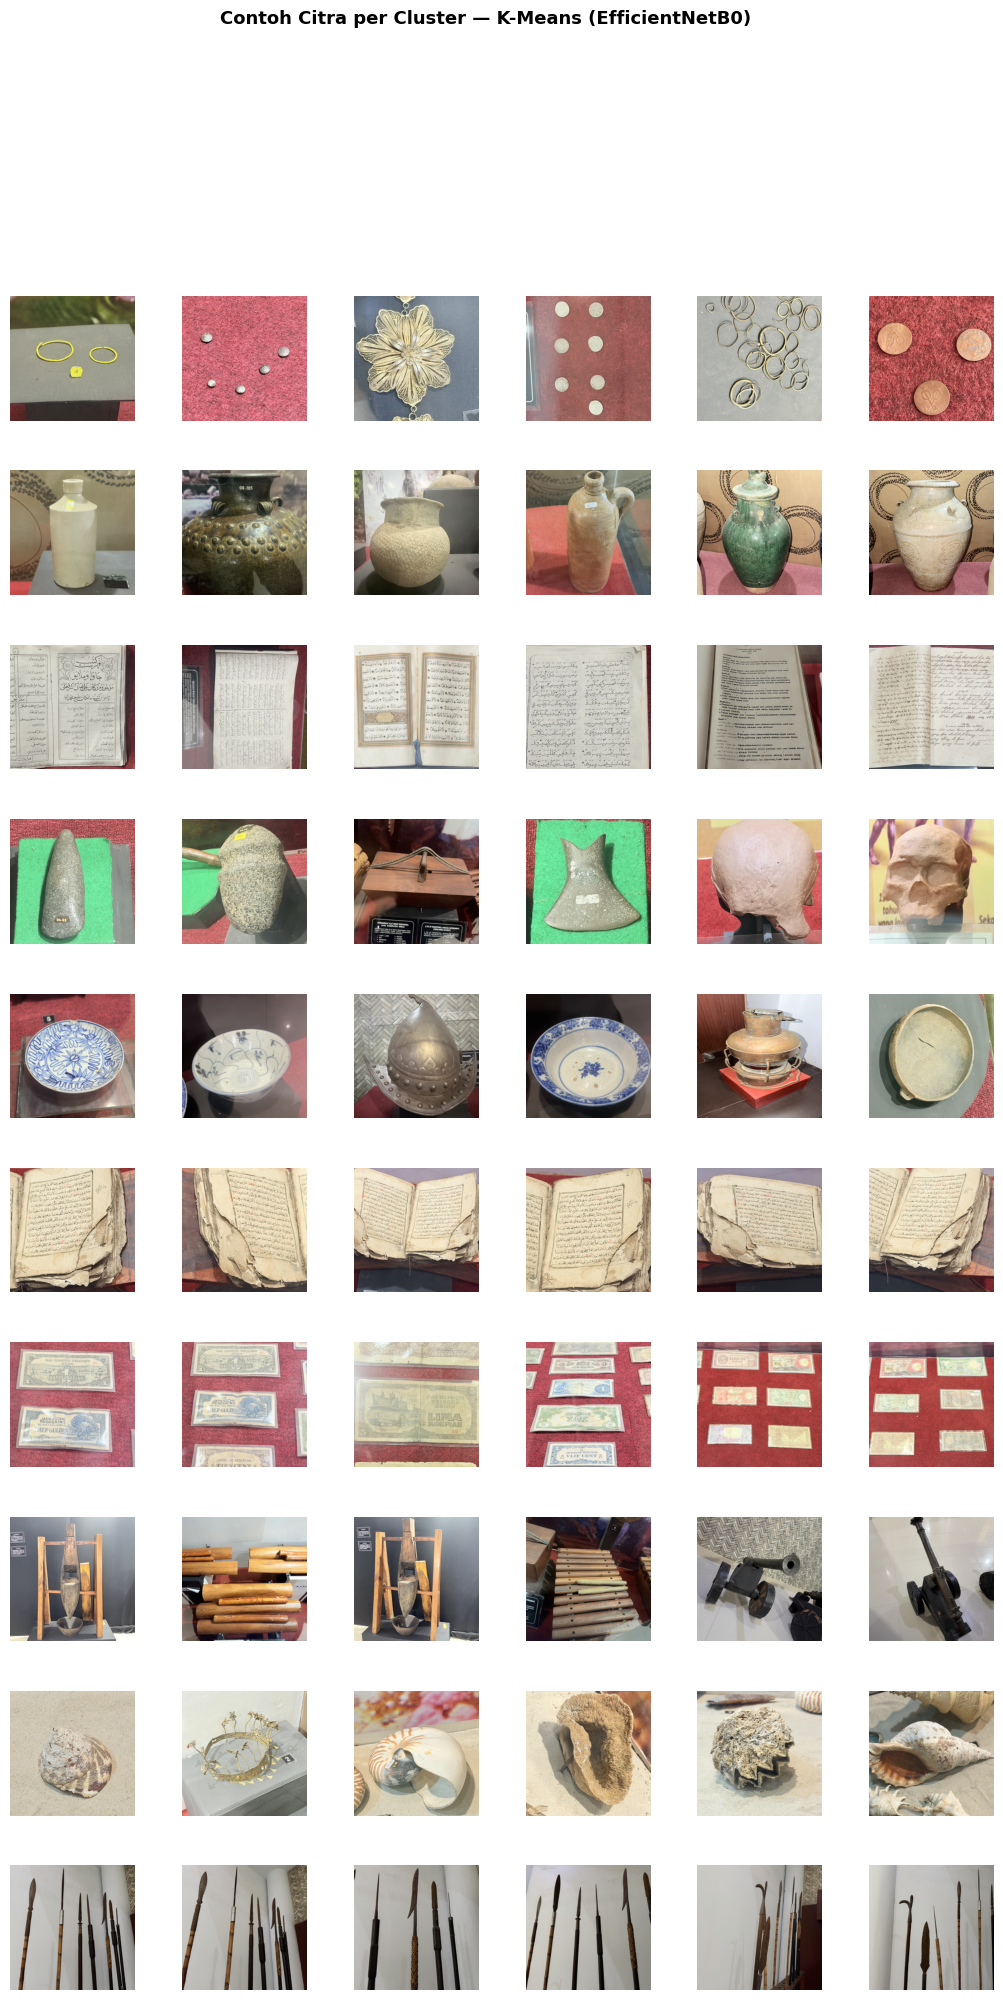

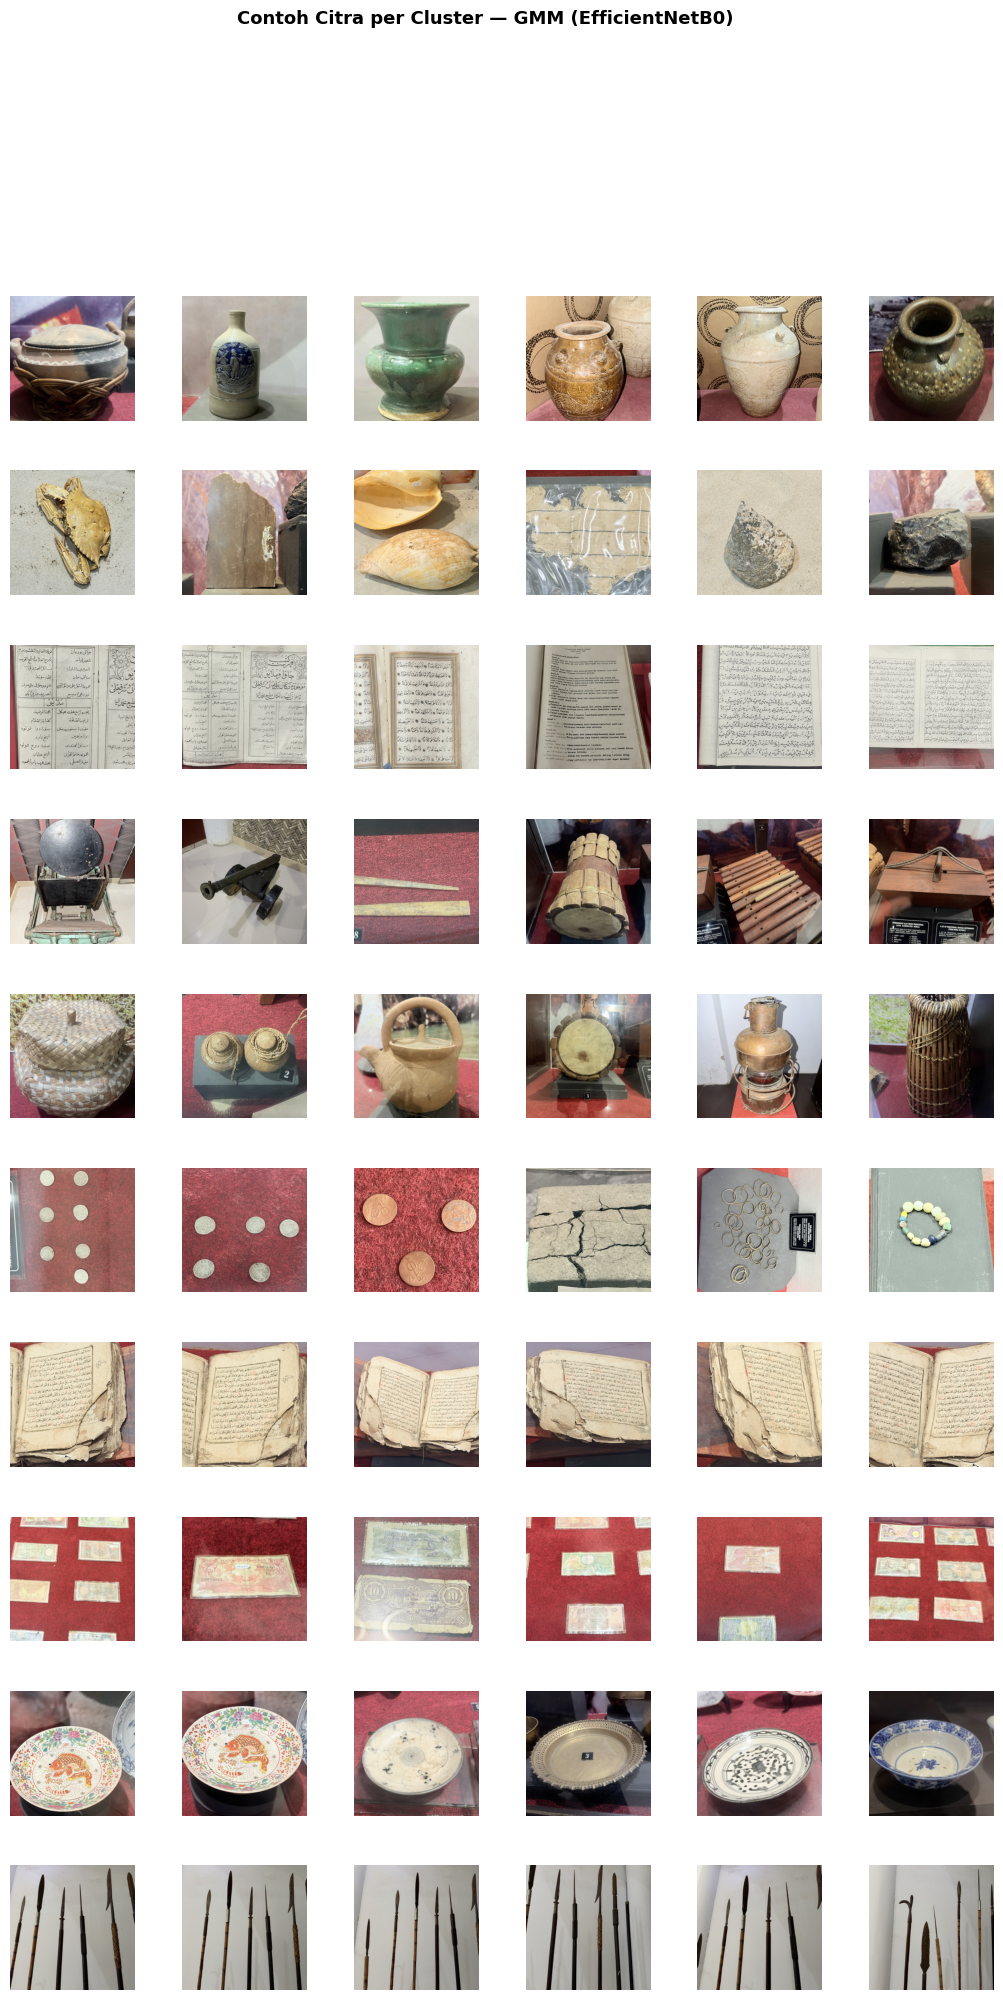

In [14]:
# ============================================================
# CELL 14: CONTOH GAMBAR PER CLUSTER
# ============================================================

def plot_cluster_samples(images, labels, name_map, n_clusters,
                          n_sample=6, title='', save_path=None):
    valid_clusters = [cl for cl in range(n_clusters) if np.any(labels == cl)]
    n_rows = len(valid_clusters)
    fig = plt.figure(figsize=(n_sample * 2.2, n_rows * 2.2))
    gs  = gridspec.GridSpec(n_rows, n_sample, figure=fig, hspace=0.4, wspace=0.05)
    cmap_fn = plt.cm.get_cmap('tab20', n_rows)

    for row_i, cl in enumerate(valid_clusters):
        idx_cl = np.where(labels == cl)[0]
        chosen = np.random.choice(idx_cl, min(n_sample, len(idx_cl)), replace=False)
        cat_name = name_map.get(cl, f'C{cl}')
        for j, img_idx in enumerate(chosen):
            ax = fig.add_subplot(gs[row_i, j])
            ax.imshow(np.clip(images[img_idx] / 255.0
                              if images[img_idx].max() > 1 else images[img_idx], 0, 1))
            ax.axis('off')
            if j == 0:
                ax.set_ylabel(f'C{cl}\n({len(idx_cl)})\n{cat_name}',
                              fontsize=7, rotation=0, labelpad=60, va='center',
                              color=cmap_fn(row_i))
    fig.suptitle(f'Contoh Citra per Cluster — {title}', fontsize=13,
                 fontweight='bold', y=1.01)
    if save_path:
        plt.savefig(save_path, dpi=130, bbox_inches='tight')
    plt.show()


km_cluster_names  = {cl: class_names[gt_idx] for cl, gt_idx in map_km.items()}
gmm_cluster_names = {cl: class_names[gt_idx] for cl, gt_idx in map_gmm.items()}

plot_cluster_samples(
    images, km_labels, km_cluster_names, N_CLUSTERS,
    n_sample=CONFIG['n_sample_vis'], title='K-Means (EfficientNetB0)',
    save_path=os.path.join(CONFIG['output_root'], 'grafik', '07_cluster_kmeans.png')
)
plot_cluster_samples(
    images, gmm_labels, gmm_cluster_names, N_CLUSTERS,
    n_sample=CONFIG['n_sample_vis'], title='GMM (EfficientNetB0)',
    save_path=os.path.join(CONFIG['output_root'], 'grafik', '08_cluster_gmm.png')
)


## Cell 15 — Simpan Gambar ke Folder + Manifest CSV

In [15]:
# ============================================================
# CELL 15: SIMPAN GAMBAR KE FOLDER CLUSTER
# ============================================================

def save_clusters(image_paths, labels, n_clusters, output_dir,
                  method_name='kmeans', cluster_names=None):
    base_dir = os.path.join(output_dir, f'cluster_{method_name}')
    unique_labels = sorted(set(labels))
    for cl in unique_labels:
        if cl == -1: folder_name = 'noise'
        else:
            cat = cluster_names.get(cl, 'unknown') if cluster_names else 'unknown'
            folder_name = f'cluster_{cl:02d}__{cat.replace(" ", "_")}'
        os.makedirs(os.path.join(base_dir, folder_name), exist_ok=True)

    manifest = []
    for path, lbl in tqdm(zip(image_paths, labels), total=len(image_paths),
                           desc=f'Simpan {method_name}'):
        fname = os.path.basename(path)
        if lbl == -1: folder_name = 'noise'
        else:
            cat = cluster_names.get(int(lbl), 'unknown') if cluster_names else 'unknown'
            folder_name = f'cluster_{lbl:02d}__{cat.replace(" ", "_")}'
        dest = os.path.join(base_dir, folder_name, fname)
        if os.path.exists(dest):
            base, ext = os.path.splitext(fname)
            dest = os.path.join(base_dir, folder_name, f'{base}_{np.random.randint(9999)}{ext}')
        shutil.copy2(path, dest)
        manifest.append({'path': path, 'cluster': int(lbl),
                          'category': cluster_names.get(int(lbl), '?') if cluster_names and lbl != -1 else 'noise',
                          'gt_folder': os.path.basename(os.path.dirname(path)), 'dest': dest})

    mpath = os.path.join(output_dir, f'manifest_{method_name}.csv')
    with open(mpath, 'w', newline='', encoding='utf-8') as f:
        w = csv.DictWriter(f, fieldnames=list(manifest[0].keys()))
        w.writeheader(); w.writerows(manifest)
    print(f'[{method_name}] Selesai → {base_dir}')
    return manifest


save_clusters(image_paths, km_labels,  N_CLUSTERS, CONFIG['output_root'],
              'kmeans',  km_cluster_names)
save_clusters(image_paths, gmm_labels, N_CLUSTERS, CONFIG['output_root'],
              'gmm',     gmm_cluster_names)
if HDBSCAN_AVAILABLE and hdb_labels is not None:
    n_hdb_cl = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
    save_clusters(image_paths, hdb_labels, n_hdb_cl, CONFIG['output_root'],
                  'hdbscan', {})


Simpan kmeans: 100%|██████████| 593/593 [00:02<00:00, 271.03it/s]


[kmeans] Selesai → /Users/mdaffaatstsaqif/Downloads/klaster asli/hasil_transfer/cluster_kmeans


Simpan gmm: 100%|██████████| 593/593 [00:01<00:00, 429.44it/s]


[gmm] Selesai → /Users/mdaffaatstsaqif/Downloads/klaster asli/hasil_transfer/cluster_gmm


Simpan hdbscan: 100%|██████████| 593/593 [00:01<00:00, 579.92it/s]

[hdbscan] Selesai → /Users/mdaffaatstsaqif/Downloads/klaster asli/hasil_transfer/cluster_hdbscan


## Cell 16 — Ringkasan Akhir

In [16]:
# ============================================================
# CELL 16: RINGKASAN AKHIR
# ============================================================

print('\n' + '='*70)
print(' RINGKASAN AKHIR — TRANSFER LEARNING CLUSTERING')
print('='*70)
print(f'Dataset         : {len(images)} gambar, {len(class_names)} kategori museum')
print(f'Feature extractor: {CONFIG["backbone"]} pretrained ImageNet (frozen)')
print(f'Feature dim     : {features_raw.shape[1]}D → {features_final.shape[1]}D ({REDUCTION_METHOD})')
print(f'K Optimal       : {K_OPTIMAL} (dari Silhouette search K=2..15)')
print()
print(f'{"Metode":<22} {"Silhouette":>12} {"DBI":>10} {"CHI":>12} {"Acc(Hungarian)":>16}')
print('-'*76)
print(f'{"K-Means (K=opt)":<22} {km_scores_opt["sil"]:>12.4f} {km_scores_opt["dbi"]:>10.4f} {km_scores_opt["chi"]:>12.1f} {"N/A":>16}')
print(f'{"K-Means (K=10)":<22} {km_scores_10["sil"]:>12.4f} {km_scores_10["dbi"]:>10.4f} {km_scores_10["chi"]:>12.1f} {acc_km*100:>15.2f}%')
print(f'{"GMM (K=10)":<22} {gmm_scores["sil"]:>12.4f} {gmm_scores["dbi"]:>10.4f} {gmm_scores["chi"]:>12.1f} {acc_gmm*100:>15.2f}%')
if HDBSCAN_AVAILABLE and hdb_scores['sil']:
    print(f'{"HDBSCAN (auto)":<22} {hdb_scores["sil"]:>12.4f} {hdb_scores["dbi"]:>10.4f} {"N/A":>12} {"N/A":>16}')
print('='*76)
print(f'\nMetode terbaik (Silhouette): {BEST_METHOD} = {BEST_SIL:.4f}')
print(f'Output tersimpan di        : {CONFIG["output_root"]}')
print('='*70)

# Simpan JSON ringkasan
summary = {
    'backbone': CONFIG['backbone'],
    'reduction': REDUCTION_METHOD,
    'n_images': len(images),
    'n_classes': len(class_names),
    'class_names': class_names,
    'k_optimal': int(K_OPTIMAL),
    'results': {
        'kmeans_opt': {'k': int(K_OPTIMAL), **{k: float(v) for k, v in km_scores_opt.items()}},
        'kmeans_10' : {'k': 10, 'acc': float(acc_km), **{k: float(v) for k, v in km_scores_10.items()}},
        'gmm_10'    : {'k': 10, 'acc': float(acc_gmm), **{k: float(v) for k, v in gmm_scores.items()}},
    }
}
with open(os.path.join(CONFIG['output_root'], 'ringkasan_final.json'), 'w') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print('Notebook Transfer Learning Clustering selesai!')



 RINGKASAN AKHIR — TRANSFER LEARNING CLUSTERING
Dataset         : 593 gambar, 10 kategori museum
Feature extractor: EfficientNetB0 pretrained ImageNet (frozen)
Feature dim     : 1280D → 50D (PCA128D + UMAP50D)
K Optimal       : 2 (dari Silhouette search K=2..15)

Metode                   Silhouette        DBI          CHI   Acc(Hungarian)
----------------------------------------------------------------------------
K-Means (K=opt)              0.6338     0.3247        340.1              N/A
K-Means (K=10)               0.5329     0.5886       1074.5           47.89%
GMM (K=10)                   0.5157     0.6522       1041.7           46.04%
HDBSCAN (auto)               0.6225     0.4871          N/A              N/A

Metode terbaik (Silhouette): K-Means (K=opt) = 0.6338
Output tersimpan di        : /Users/mdaffaatstsaqif/Downloads/klaster asli/hasil_transfer
Notebook Transfer Learning Clustering selesai!
